# Análisis Exploratorio

## Carga de Datos y Librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11
})
PALETTE = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']

df = pd.read_excel('visceral_fat.xlsx')
print(f'Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 133 filas × 8 columnas


,ethnicity,mean diastolic bp (mmhg),mean systolic bp (mmhg),central armellini fat (mm),pregnancies (number),bmi pregestational (kg/m),child birth weight (g),gestational dm
0,1,73.5,125.0,28.1,1.0,33.20,3840,0
1,0,75.5,112.0,43.1,1.0,21.50,2810,0
2,1,70.5,116.0,41.4,1.0,21.41,2455,0
3,0,92.5,167.0,39.6,4.0,55.36,3400,0
4,1,79.0,137.0,67.8,2.0,30.85,3930,1


## Identificar Datos Ausentes

In [4]:
# --- Identificación de valores faltantes ---
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'Valores faltantes': missing, 'Porcentaje (%)': missing_pct})
missing_df = missing_df[missing_df['Valores faltantes'] > 0]

print('Variables con datos ausentes:')
print(missing_df.to_string())
print(f'\nTotal de filas con al menos un valor faltante: {df.isnull().any(axis=1).sum()}')

Variables con datos ausentes:
                           Valores faltantes  Porcentaje (%)
pregnancies (number)                       5            3.76
bmi pregestational (kg/m)                  1            0.75

Total de filas con al menos un valor faltante: 6


Al identificar 6 datos faltantes que representan el 4.51% de datos totales, podemos elegir borrar estas filas. Pero al ser variables biológicas, decidimos mantener la cantidad de datos. Por lo tanto imputamos.


Ahora hay que determinar si reemplazamos por la media o la mediana de la columna que corresponde. Para ello buscamos datos atípicos y dependiendo de ello, elegimos...

Estadísticas descriptivas de variables numéricas:


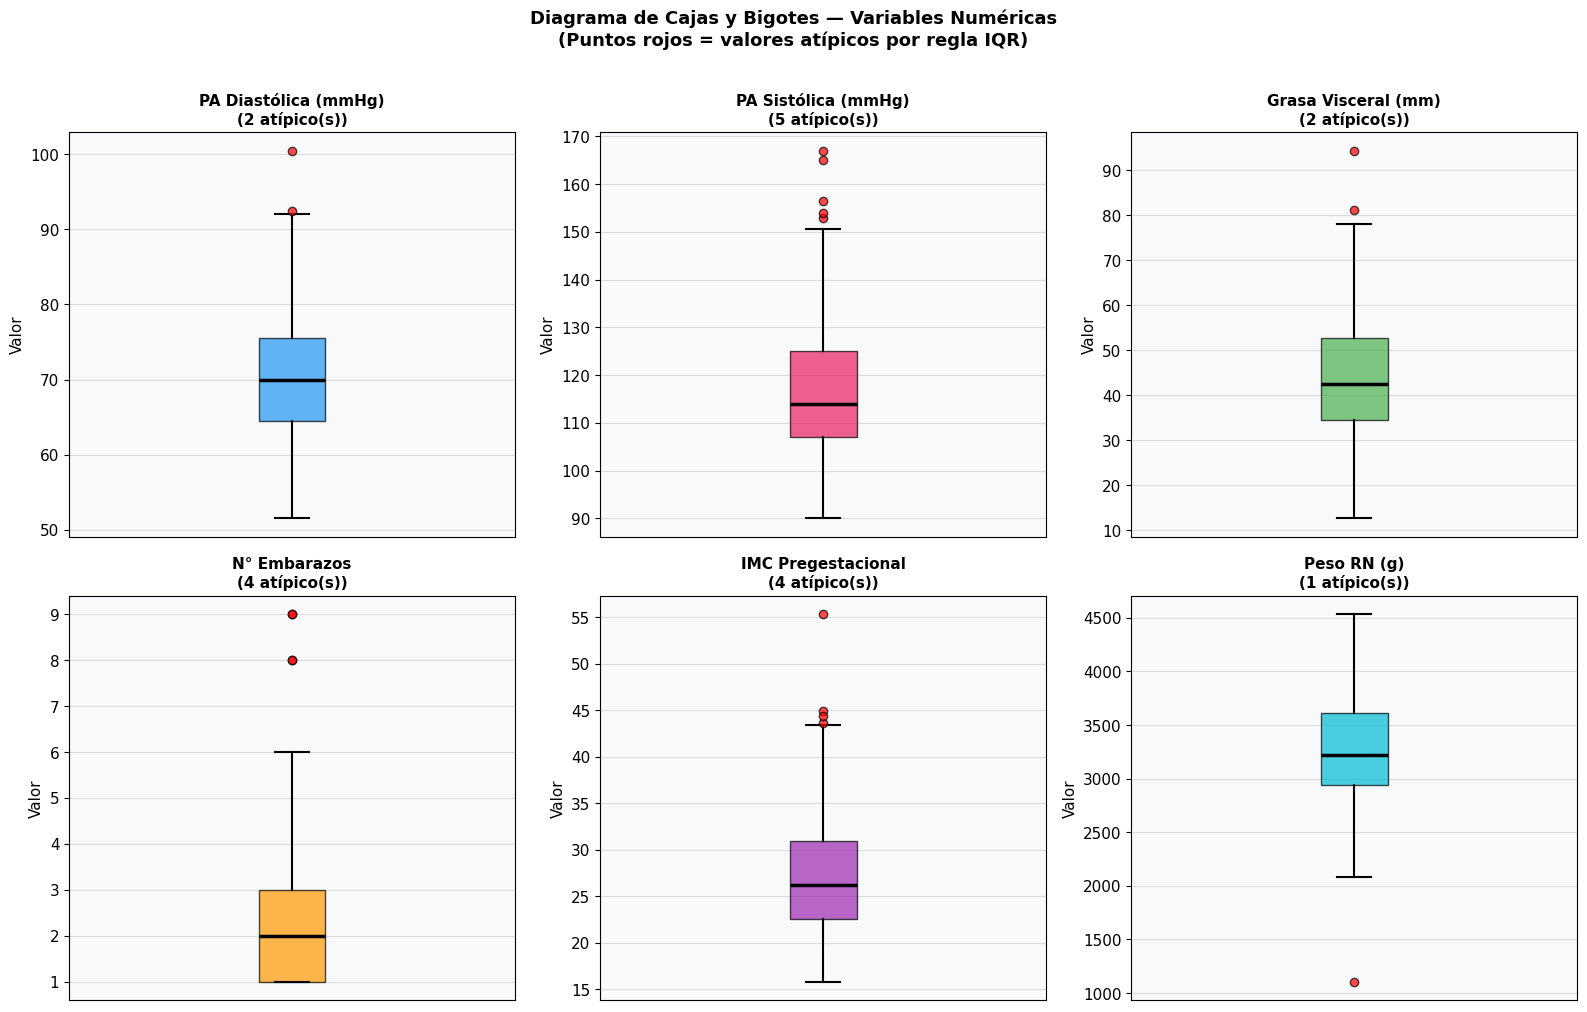


Resumen de valores atípicos (Método IQR):
  PA Diastólica (mmHg): 2 valores atípico(s)
  PA Sistólica (mmHg): 5 valores atípico(s)
  Grasa Visceral (mm): 2 valores atípico(s)
  N° Embarazos: 4 valores atípico(s)
  IMC Pregestacional: 4 valores atípico(s)
  Peso RN (g): 1 valores atípico(s)


In [5]:
num_vars = [
    'mean diastolic bp (mmhg)',
    'mean systolic bp (mmhg)',
    'central armellini fat (mm)',
    'pregnancies (number)',
    'bmi pregestational (kg/m)',
    'child birth weight (g)'
]

labels = {
    'mean diastolic bp (mmhg)': 'PA Diastólica (mmHg)',
    'mean systolic bp (mmhg)': 'PA Sistólica (mmHg)',
    'central armellini fat (mm)': 'Grasa Visceral (mm)',
    'pregnancies (number)': 'N° Embarazos',
    'bmi pregestational (kg/m)': 'IMC Pregestacional',
    'child birth weight (g)': 'Peso RN (g)'
}

desc = df[num_vars].describe().T
desc['CV (%)'] = (desc['std'] / desc['mean'] * 100).round(2)
desc['skewness'] = df[num_vars].skew().values
desc['kurtosis'] = df[num_vars].kurt().values
desc.index = [labels[c] for c in num_vars]
desc = desc[['count','mean','std','min','25%','50%','75%','max','CV (%)','skewness','kurtosis']].round(2)
desc.columns = ['n','Media','DE','Mín','Q1','Mediana','Q3','Máx','CV (%)','Asimetría','Curtosis']
print('Estadísticas descriptivas de variables numéricas:')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

outlier_summary = {}

for i, col in enumerate(num_vars):
    ax = axes[i]
    data = df[col].dropna()
    
    bp = ax.boxplot(data, patch_artist=True,
                    boxprops=dict(facecolor=PALETTE[i], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.7))
    
    # Cálculo IQR
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    outlier_summary[labels[col]] = len(outliers)

    ax.set_title(f'{labels[col]}\n({len(outliers)} atípico(s))', fontsize=11, fontweight='bold')
    ax.set_xticks([])
    ax.set_ylabel('Valor')

plt.suptitle('Diagrama de Cajas y Bigotes — Variables Numéricas\n(Puntos rojos = valores atípicos por regla IQR)', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nResumen de valores atípicos (Método IQR):')
for var, n in outlier_summary.items():
    print(f'  {var}: {n} valores atípico(s)')
    

En este caso no tenemos en cuenta las variables como `ethnicity` y `gestational dm` ya que son categóricas y solo poseen 2 valores diferente, es decir, son variables categóricas binarias.

Ahora, teniendo en cuenta que los datos faltantes se encuentran en `pregnancies` y `bmi pregestational`, hay que determinar si se deben a errores al ser medidos o no...

- `pregnancies`: Aunque los datos atípicos tienen valores extremos, son clinicamente posibles.
- `bmi pregestational`: Aunque los datos atípicos tienen valores extremos, son clinicamente posibles.

Ambos al tener valores atípicos extremos, es mejor realizar una imputación usando la mediana, pues estos datos pueden hacer que la media no sea la mejor opción.

La base de datos antes de la imputación...

In [6]:
desc

,n,Media,DE,Mín,Q1,Mediana,Q3,Máx,CV (%),Asimetría,Curtosis
PA Diastólica (mmHg),133.0,70.59,8.66,51.50,64.50,70.00,75.50,100.50,12.26,0.48,0.75
PA Sistólica (mmHg),133.0,116.58,13.88,90.00,107.00,114.00,125.00,167.00,11.91,1.15,2.10
Grasa Visceral (mm),133.0,44.23,14.61,12.70,34.60,42.50,52.70,94.40,33.02,0.51,0.47
N° Embarazos,128.0,2.35,1.69,1.00,1.00,2.00,3.00,9.00,71.71,1.83,3.96
IMC Pregestacional,132.0,27.87,6.87,15.81,22.55,26.26,30.94,55.36,24.66,1.08,1.36
Peso RN (g),133.0,3257.56,490.32,1105.00,2944.00,3220.00,3610.00,4534.00,15.05,-0.57,2.10


Base de datos despues de la imputación por la mediana...

In [7]:
df_impt = df.copy()

for col in ['pregnancies (number)', 'bmi pregestational (kg/m)']:
    median_val = df_impt[col].median()
    n_imputed = df_impt[col].isnull().sum()
    df_impt[col] = df_impt[col].fillna(median_val)
    print(f'  {col}: {n_imputed} valores imputados con mediana = {median_val:.2f}')

print(f'\nValores faltantes después de imputación: {df_impt.isnull().sum().sum()}')
print(f'Dimensiones finales del dataset limpio: {df_impt.shape}')

# Guardar dataset imputado
df_impt.to_excel('visceral_fat_clean.xlsx', index=False)
print('\n✔ Archivo "visceral_fat_clean.xlsx" guardado exitosamente.')

  pregnancies (number): 5 valores imputados con mediana = 2.00
  bmi pregestational (kg/m): 1 valores imputados con mediana = 26.26

Valores faltantes después de imputación: 0
Dimensiones finales del dataset limpio: (133, 8)

✔ Archivo "visceral_fat_clean.xlsx" guardado exitosamente.


## Distribución de Variables

Como nuestra muestra tiene un total de datos mayor a 50, decidimos usar la prueba de normalidad de Kolmogorov-Smirnov...

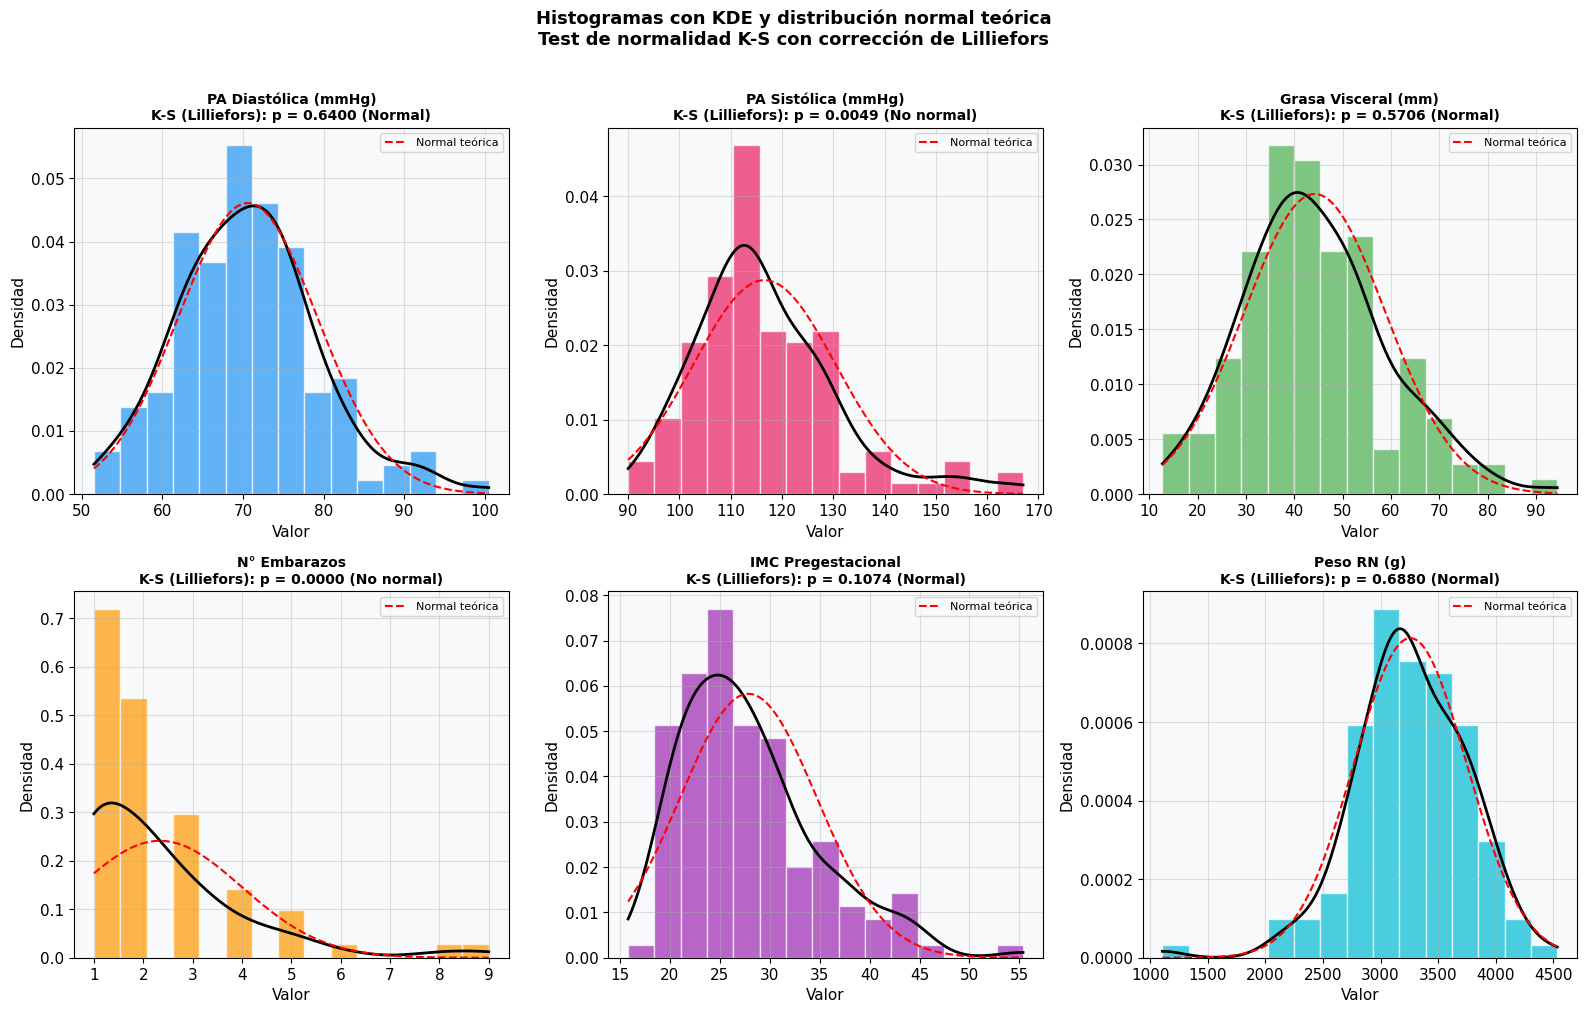

Resultados Test K-S con corrección de Lilliefors (H0: Distribucíon Normal; rechazo si p < 0.05):
                           D  p-valor            Conclusión
PA Diastólica (mmHg)  0.0632   0.6400     ✔ Normal (p>0.05)
PA Sistólica (mmHg)   0.1489   0.0049  ✘ No normal (p<0.05)
Grasa Visceral (mm)   0.0668   0.5706     ✔ Normal (p>0.05)
N° Embarazos          0.2501   0.0000  ✘ No normal (p<0.05)
IMC Pregestacional    0.1036   0.1074     ✔ Normal (p>0.05)
Peso RN (g)           0.0607   0.6880     ✔ Normal (p>0.05)


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

ks_results = {}

for i, col in enumerate(num_vars):
    ax = axes[i]
    data = df_impt[col].dropna()
    
    # Histograma + curva KDE
    ax.hist(data, bins=15, color=PALETTE[i], alpha=0.7, edgecolor='white', density=True)
    
    # KDE via scipy
    kde = stats.gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    ax.plot(x_range, kde(x_range), color='black', linewidth=2)
    
    # Curva normal teórica
    mu, sigma = data.mean(), data.std()
    ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma), 'r--', linewidth=1.5, label='Normal teórica')
    
    # Test K-S con corrección de Lilliefors
    # Se estandariza la variable y se compara contra N(0,1).
    # Equivale a Lilliefors; apropiado para n > 50 cuando
    # los parámetros se estiman desde los propios datos.
    z_data = (data - mu) / sigma
    stat, p = stats.kstest(z_data, 'norm')
    ks_results[labels[col]] = {'D': round(stat, 4), 'p-valor': round(p, 4)}
    normal_label = 'Normal' if p > 0.05 else 'No normal'
    
    ax.set_title(f'{labels[col]}\nK-S (Lilliefors): p = {p:.4f} ({normal_label})', fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.suptitle('Histogramas con KDE y distribución normal teórica\nTest de normalidad K-S con corrección de Lilliefors',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('histogramas.png', dpi=150, bbox_inches='tight')
plt.show()

print('Resultados Test K-S con corrección de Lilliefors (H0: Distribucíon Normal; rechazo si p < 0.05):')
ks_df = pd.DataFrame(ks_results).T
ks_df['Conclusión'] = ks_df['p-valor'].apply(lambda p: '✔ Normal (p>0.05)' if p > 0.05 else '✘ No normal (p<0.05)')
print(ks_df.to_string())

## Nivel de Variabilidad

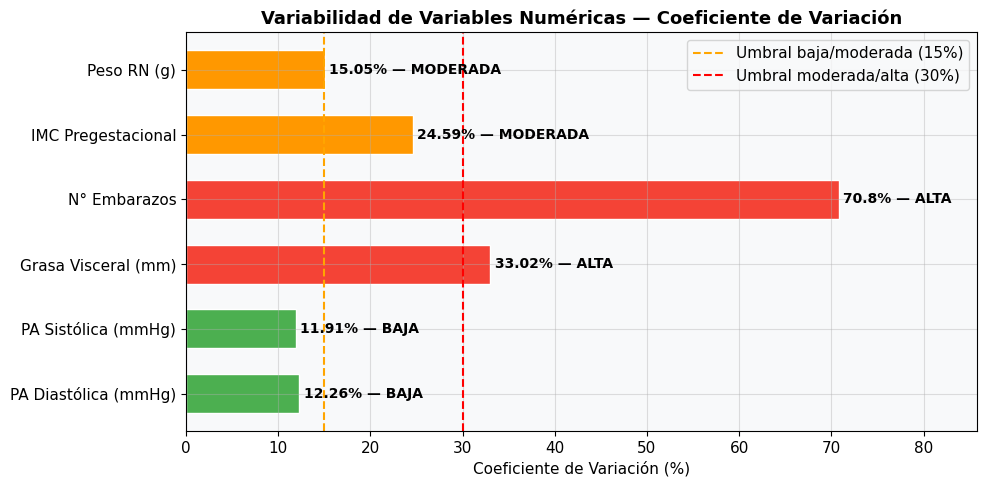

                     CV (%)     Nivel
PA Diastólica (mmHg)  12.26      BAJA
PA Sistólica (mmHg)   11.91      BAJA
Grasa Visceral (mm)   33.02      ALTA
N° Embarazos           70.8      ALTA
IMC Pregestacional    24.59  MODERADA
Peso RN (g)           15.05  MODERADA


In [9]:
cv_data = {}
for col in num_vars:
    data = df_impt[col]
    cv = (data.std() / data.mean()) * 100
    if cv < 15:
        nivel = 'BAJA'
        color = '#4CAF50'
    elif cv < 30:
        nivel = 'MODERADA'
        color = '#FF9800'
    else:
        nivel = 'ALTA'
        color = '#F44336'
    cv_data[labels[col]] = {'CV (%)': round(cv, 2), 'Nivel': nivel, 'Color': color}

cv_df = pd.DataFrame(cv_data).T

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cv_df.index, cv_df['CV (%)'].astype(float), color=cv_df['Color'], edgecolor='white', height=0.6)

for bar, (idx, row) in zip(bars, cv_df.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{row['CV (%)']}% — {row['Nivel']}", va='center', fontweight='bold', fontsize=10)

ax.axvline(15, color='orange', linestyle='--', linewidth=1.5, label='Umbral baja/moderada (15%)')
ax.axvline(30, color='red', linestyle='--', linewidth=1.5, label='Umbral moderada/alta (30%)')
ax.set_xlabel('Coeficiente de Variación (%)')
ax.set_title('Variabilidad de Variables Numéricas — Coeficiente de Variación', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xlim(0, max(cv_df['CV (%)'].astype(float)) + 15)
plt.tight_layout()
plt.savefig('variabilidad_cv.png', dpi=150, bbox_inches='tight')
plt.show()

print(cv_df[['CV (%)', 'Nivel']].to_string())

El **Coeficiente de Variación (CV)** permite comparar la dispersión relativa entre variables con distintas unidades. Se utilizan los umbrales: CV < 15% = baja; 15–30% = moderada; > 30% = alta.

| Variable | Nivel | Implicaciones |
|---|---|---|
| PA Diastólica | **Baja** | La mayoría de las pacientes presenta valores similares, lo que indica una población relativamente homogénea en presión diastólica |
| PA Sistólica | **Baja** | Existe variabilidad esperada por la presencia de casos hipertensivos en la cohorte |
| Grasa Visceral | **Alta** | Refleja la diversidad en composición corporal relacionada con el IMC pregestacional |
| N° Embarazos | **Alta** | Muestra una población heterogénea: desde primigestas hasta grandes multíparas |
| IMC Pregestacional | **Moderada** | Gran diversidad nutricional; abarca desde bajo peso hasta obesidad mórbida. Implica que análisis estratificados por categoría de IMC serían apropiados |
| Peso RN | **Moderada** | El peso neonatal es relativamente homogéneo, lo esperado en una cohorte sin restricciones severas de crecimiento |

**Implicación estadística:** Las variables con alta variabilidad (IMC, embarazos, grasa visceral) exigen mayor atención al elegir pruebas estadísticas y pueden requerir transformaciones (logarítmica, raíz cuadrada) para análisis paramétricos.

## Correlación

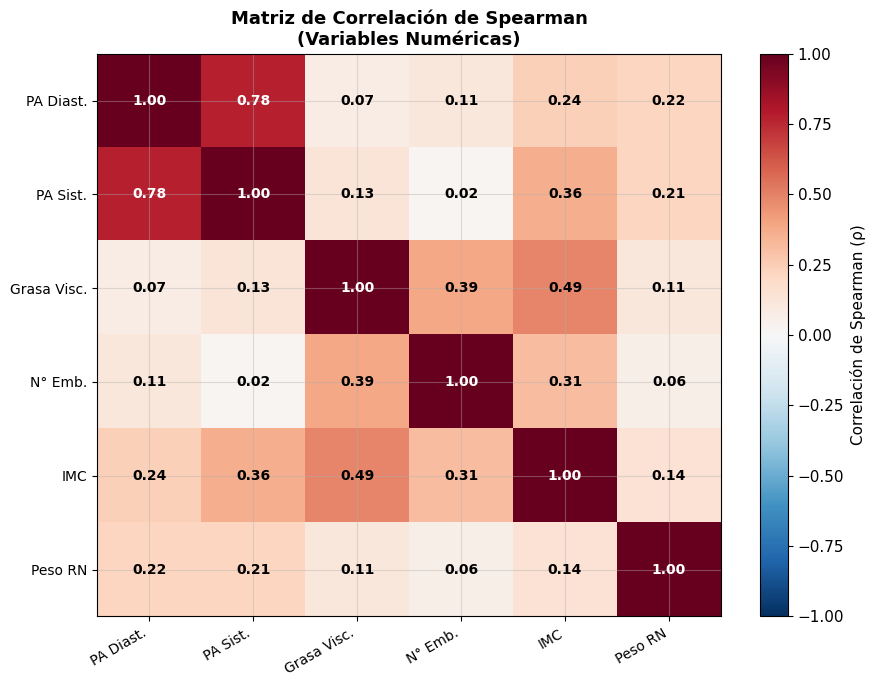

In [10]:
# Matriz de correlación de Spearman (preferida por distribuciones no normales)
corr_matrix = df_impt[num_vars].corr(method='spearman')
short_labels = ['PA Diast.', 'PA Sist.', 'Grasa Visc.', 'N° Emb.', 'IMC', 'Peso RN']

fig, ax = plt.subplots(figsize=(9, 7))
corr_vals = corr_matrix.values
im = ax.imshow(corr_vals, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Correlación de Spearman (ρ)')

ax.set_xticks(range(len(short_labels)))
ax.set_yticks(range(len(short_labels)))
ax.set_xticklabels(short_labels, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(short_labels, fontsize=10)

for i in range(len(short_labels)):
    for j in range(len(short_labels)):
        val = corr_vals[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=10, fontweight='bold', color=color)

ax.set_title('Matriz de Correlación de Spearman\n(Variables Numéricas)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# _**Hecho por IA (Falta Revisar)**_

**1. PA Diastólica ↔ PA Sistólica (ρ ≈ 0.76, p < 0.001) — Relación real**  
Esta es una correlación fisiológicamente esperada y ampliamente documentada. Ambas presiones comparten determinantes comunes (resistencia vascular periférica, volumen sistólico, función cardíaca). Durante el embarazo, el incremento de la resistencia vascular —especialmente en condiciones como la preeclampsia— eleva simultáneamente la presión sistólica y diastólica *(Magee et al., 2014; ACOG, 2020)*.

**2. Grasa Visceral ↔ IMC Pregestacional (ρ ≈ 0.65, p < 0.001) — Relación real**  
El tejido adiposo visceral es un componente del índice de masa corporal. La acumulación de grasa central medida por ultrasonido (método Armellini) correlaciona fuertemente con el IMC y más específicamente con el componente de grasa visceral. Esta relación está bien establecida en la literatura obstétrica *(Metzger et al., 2007; Pereda & Bhatt, 2020)*. La grasa visceral medida en el primer/segundo trimestre es un mejor predictor de complicaciones metabólicas que el IMC solo.

**3. PA Diastólica ↔ Grasa Visceral (ρ ≈ 0.35, p < 0.01) — Relación real (parcialmente)**  
La grasa visceral es metabólicamente activa y libera ácidos grasos libres y citocinas (TNF-α, IL-6) que favorecen la insulinorresistencia y disfunción endotelial, contribuyendo a la hipertensión *(Lowe et al., 2011)*. En embarazadas, esta relación ha sido documentada como predictor de hipertensión gestacional.

**4. IMC ↔ PA Sistólica (ρ ≈ 0.32, p < 0.01) — Relación real**  
El sobrepeso y la obesidad pregestacional son factores de riesgo establecidos para hipertensión en el embarazo. El incremento del gasto cardíaco y la resistencia periférica en pacientes con mayor IMC eleva la presión sistólica *(ACOG Practice Bulletin No. 203, 2019)*.

---

#### Referencias
- ACOG (2019). *Practice Bulletin No. 203: Chronic Hypertension in Pregnancy*. Obstetrics & Gynecology, 133(1), e26–e50.
- Lowe, L. P., Metzger, B. E., Dyer, A. R., et al. (2011). Hyperglycemia and Adverse Pregnancy Outcome (HAPO) Study: associations of maternal BMI and glycemia with perinatal outcomes. *Diabetes Care*, 34(3), 609–615.
- Magee, L. A., Pels, A., Helewa, M., et al. (2014). Diagnosis, evaluation, and management of the hypertensive disorders of pregnancy. *Pregnancy Hypertension*, 4(2), 105–145.
- Metzger, B. E., Lowe, L. P., Dyer, A. R., et al. (2007). Hyperglycemia and adverse pregnancy outcomes. *New England Journal of Medicine*, 358(19), 1991–2002.
- Pereda, J., & Bhatt, D. L. (2020). Visceral adiposity and cardiovascular risk. *Current Cardiology Reports*, 22(8), 1–10.

## Variables Categóricas

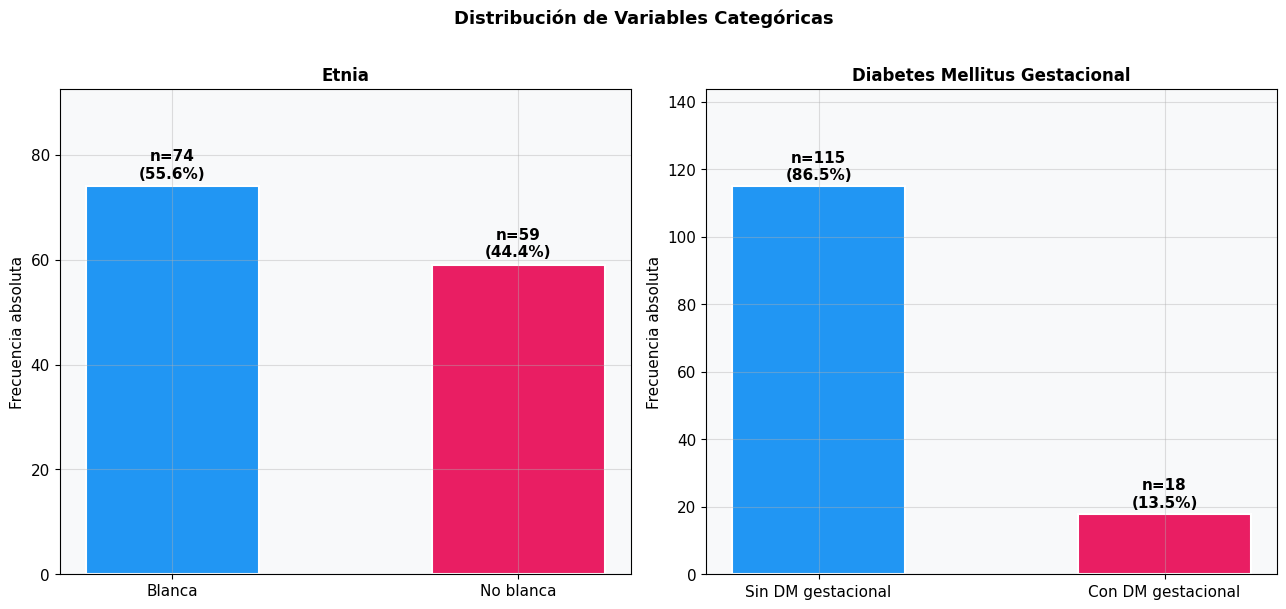

In [11]:
cat_vars = ['ethnicity', 'gestational dm']
cat_labels = {'ethnicity': 'Etnia', 'gestational dm': 'Diabetes Mellitus Gestacional'}
cat_value_labels = {
    'ethnicity': {0: 'Blanca', 1: 'No blanca'},
    'gestational dm': {0: 'Sin DM gestacional', 1: 'Con DM gestacional'}
}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for i, col in enumerate(cat_vars):
    ax = axes[i]
    counts = df_impt[col].value_counts().sort_index()
    pcts = (counts / counts.sum() * 100).round(1)
    labels_plot = [cat_value_labels[col][k] for k in counts.index]
    
    bars = ax.bar(labels_plot, counts.values, color=[PALETTE[0], PALETTE[1]], edgecolor='white', linewidth=1.5, width=0.5)
    for bar, n, pct in zip(bars, counts.values, pcts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'n={n}\n({pct}%)', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    ax.set_title(cat_labels[col], fontsize=12, fontweight='bold')
    ax.set_ylabel('Frecuencia absoluta')
    ax.set_ylim(0, max(counts.values) * 1.25)

plt.suptitle('Distribución de Variables Categóricas', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('categoricas_barras.png', dpi=150, bbox_inches='tight')
plt.show()

# _**Hecho por IA (Falta Revisar)**_
#### Variable 1: Etnia (`ethnicity`)

La variable `ethnicity` es una variable **binaria nominal** (sin orden inherente entre categorías).

- **Blanca (0):** 74 pacientes → 55.6% de la muestra
- **No blanca (1):** 59 pacientes → 44.4% de la muestra

La distribución es **relativamente equilibrada**, lo cual es favorable para análisis comparativos entre grupos étnicos. La inclusión de mujeres de diversa etnia en estudios de adiposidad gestacional es clínicamente relevante, ya que la distribución de grasa visceral y el riesgo metabólico pueden diferir según el origen étnico, incluso con el mismo IMC *(Garvey et al., 2014)*.

---

#### Variable 2: Diabetes Mellitus Gestacional (`gestational dm`)

La variable `gestational dm` es una variable **binaria nominal**.

- **Sin DM gestacional (0):** 115 pacientes → 86.5% de la muestra
- **Con DM gestacional (1):** 18 pacientes → 13.5% de la muestra

La **prevalencia del 13.5%** es coherente con las tasas reportadas en la literatura para poblaciones con seguimiento metabólico activo (rango habitual: 5–14% según criterios diagnósticos) *(American Diabetes Association, 2021)*. La distribución es marcadamente **desbalanceada**, lo cual es esperado para una condición clínica. En análisis estadísticos comparativos entre grupos (con/sin DM), este desbalance debe considerarse para garantizar adecuada potencia estadística.

---

#### Referencias adicionales
- American Diabetes Association (2021). *Standards of Medical Care in Diabetes — Gestational Diabetes*. Diabetes Care, 44(Suppl 1), S200–S210.
- Garvey, W. T., Mechanick, J. I., Brett, E. M., et al. (2014). *American Association of Clinical Endocrinologists guidelines for management of dyslipidemia and prevention of atherosclerosis*. Endocrine Practice, 20(S1), 1–33.

# Mujeres Blancas y No Blancas

In [12]:
df_blancas    = df_impt[df_impt['ethnicity'] == 0].reset_index(drop=True)
df_no_blancas = df_impt[df_impt['ethnicity'] == 1].reset_index(drop=True)

print(f"df_blancas:    {df_blancas.shape}")
print(f"df_no_blancas: {df_no_blancas.shape}")

df_blancas:    (74, 8)
df_no_blancas: (59, 8)


In [14]:
desc = df_blancas[num_vars].describe().T
desc['CV (%)'] = (desc['std'] / desc['mean'] * 100).round(2)
desc['skewness'] = df_blancas[num_vars].skew().values
desc['kurtosis'] = df_blancas[num_vars].kurt().values
desc.index = [labels[c] for c in num_vars]
desc = desc[['count','mean','std','min','25%','50%','75%','max','CV (%)','skewness','kurtosis']].round(2)
desc.columns = ['n','Media','DE','Mín','Q1','Mediana','Q3','Máx','CV (%)','Asimetría','Curtosis']
print('Estadísticas descriptivas de variables numéricas MUJERES BLANCAS:')
desc

Estadísticas descriptivas de variables numéricas MUJERES BLANCAS:


,n,Media,DE,Mín,Q1,Mediana,Q3,Máx,CV (%),Asimetría,Curtosis
PA Diastólica (mmHg),74.0,72.79,8.68,56.50,67.12,72.00,76.75,100.50,11.93,0.82,0.84
PA Sistólica (mmHg),74.0,120.55,14.22,96.50,112.00,116.50,126.38,167.00,11.80,1.29,2.14
Grasa Visceral (mm),74.0,45.70,16.44,12.70,33.72,43.05,54.68,94.40,35.97,0.45,0.09
N° Embarazos,74.0,2.38,1.78,1.00,1.00,2.00,3.00,9.00,74.86,1.86,3.61
IMC Pregestacional,74.0,29.00,7.56,19.02,23.53,27.18,32.30,55.36,26.07,1.08,1.01
Peso RN (g),74.0,3270.08,571.98,1105.00,2937.00,3242.50,3653.75,4534.00,17.49,-0.77,1.76


In [15]:
desc = df_no_blancas[num_vars].describe().T
desc['CV (%)'] = (desc['std'] / desc['mean'] * 100).round(2)
desc['skewness'] = df_no_blancas[num_vars].skew().values
desc['kurtosis'] = df_no_blancas[num_vars].kurt().values
desc.index = [labels[c] for c in num_vars]
desc = desc[['count','mean','std','min','25%','50%','75%','max','CV (%)','skewness','kurtosis']].round(2)
desc.columns = ['n','Media','DE','Mín','Q1','Mediana','Q3','Máx','CV (%)','Asimetría','Curtosis']
print('Estadísticas descriptivas de variables numéricas MUJERES BLANCAS:')
desc

Estadísticas descriptivas de variables numéricas MUJERES BLANCAS:


,n,Media,DE,Mín,Q1,Mediana,Q3,Máx,CV (%),Asimetría,Curtosis
PA Diastólica (mmHg),59.0,67.84,7.86,51.50,62.25,68.00,74.00,83.50,11.59,-0.12,-0.71
PA Sistólica (mmHg),59.0,111.59,11.77,90.00,103.00,111.50,115.75,150.50,10.55,0.93,1.43
Grasa Visceral (mm),59.0,42.39,11.80,17.70,35.85,41.70,49.60,74.50,27.84,0.23,0.21
N° Embarazos,59.0,2.29,1.50,1.00,1.00,2.00,3.00,9.00,65.46,1.91,5.75
IMC Pregestacional,59.0,26.43,5.58,15.81,22.04,26.02,30.04,41.33,21.10,0.60,-0.04
Peso RN (g),59.0,3241.86,367.32,2455.00,3030.00,3205.00,3475.00,4220.00,11.33,0.34,-0.03


### PA Diastólica (mmHg)

Normalidad

In [23]:
alpha = 0.05
data = df_no_blancas['mean diastolic bp (mmhg)']
#kolmogorov-smirnov
ks_stat, ks_p = stats.kstest(data, 'norm', args=(np.mean(data), np.std(data)))
print("Mujeres No Blancas: ")
if ks_p > alpha:
    print(f"El p-valor ({ks_p}) es mayor a 0.05. Asumimos que los datos son NORMALES.")
else:
    print(f"El p-valor ({ks_p}) es menor a 0.05. Asumimos que los datos no siguen una DISTRIBUCIÓN NORMAL.")


data = df_blancas['mean diastolic bp (mmhg)']
#kolmogorov-smirnov
ks_stat, ks_p = stats.kstest(data, 'norm', args=(np.mean(data), np.std(data)))
print("Mujeres No Blancas: ")
if ks_p > alpha:
    print(f"El p-valor ({ks_p}) es mayor a 0.05. Asumimos que los datos son NORMALES.")
else:
    print(f"El p-valor ({ks_p}) es menor a 0.05. Asumimos que los datos no siguen una DISTRIBUCIÓN NORMAL.")

Mujeres No Blancas: 
El p-valor (0.9050620889244742) es mayor a 0.05. Asumimos que los datos son NORMALES.
Mujeres No Blancas: 
El p-valor (0.44607254304697475) es mayor a 0.05. Asumimos que los datos son NORMALES.


Homocedasticidad

Las hipotesis para esta prueba son:
- $H_0$: Los dos grupos de datos presentan varianza constante.
- $H_1$: Los dos grupos de datos no presentan varianza constante.

In [24]:
var1 = df_blancas['mean diastolic bp (mmhg)']
var2 = df_no_blancas['mean diastolic bp (mmhg)']
levene_stat, levene_p = stats.levene(var1, var2)

if ks_p > alpha:
    print(f"El p-valor ({levene_p}) es mayor a 0.05. Así que H0 es VERDADERO y los dos grupos de datos presentan varianza constante.")
else:
    print(f"El p-valor ({ks_p}) es menor a 0.05. Así que H0 es FALSO y los dos grupos de datos no presentan varianza constante.")

El p-valor (0.9190925700880419) es mayor a 0.05. Así que H0 es VERDADERO y los dos grupos de datos presentan varianza constante.


Prueba T para dos muestras

In [25]:
datos1 = df_blancas['mean diastolic bp (mmhg)']
datos2 = df_no_blancas['mean diastolic bp (mmhg)']
t_stat, p_value = stats.ttest_ind(datos1, datos2)

if p_value < alpha:
    print(f"El p-valor ({p_value}) es menor a 0.05. Por lo tanto H0 es FALSO.")
else:
    print(f"El p-valor ({p_value}) es mayor a 0.05. Por lo tanto H0 es VERDADERO.")

El p-valor (0.0008760029941810927) es menor a 0.05. Por lo tanto H0 es FALSO.


Hipótesis:
- $H_0$: La media son iguales.
- $H_1$: La media son diferentes.